# Анализ влияния погодных условий на задержки рейсов

## Цель исследования

Определить, существует ли связь между погодными условиями в аэропорту Пхукета (HKT) и задержками рейсов.

## Исследовательские вопросы

1. Влияет ли скорость ветра на задержки рейсов?
2. Влияют ли осадки на задержки рейсов?
3. Влияет ли видимость на пунктуальность рейсов?
4. Какие погодные факторы оказывают наибольшее влияние?
5. Являются ли обнаржуенная связь статитически значимой?

In [13]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
from db import get_engine

## Подключение к базе данных


In [14]:
engine = get_engine()

In [15]:
query = """
select current_database()
"""

pd.read_sql(query, engine)

,current_database
0,flight_db


## Загрузка данных

In [16]:
query = """
select * 
from analytics_marts.mart_weather_flight_impact
"""

weather_df = pd.read_sql(query, engine)
weather_df.head()

,weather_key,weather_time_utc,weather_date,weather_hour,weather_day_of_week,operation_type,temperature_2m_c,apparent_temperature_c,dewpoint_2m_c,relative_humidity_2m_pct,...,is_low_visibility,total_operations,avg_delay_minutes,avg_positive_delay_minutes,delayed_operations,minor_delay_operations,ontime_operations,unknown_operations,delay_rate,ontime_rate
0,35512186d35cf2c57c170e6ce1c6ed52,2025-11-21 10:00:00,2025-11-21,10.0,Friday,arrival,26.8,31.0,23.3,81.0,...,False,1,570.0,570.0,1,0,0,0,1.0,0.0
1,a37d420719141b29a14f3437b7bc7010,2025-11-21 11:00:00,2025-11-21,11.0,Friday,departure,26.5,30.8,23.2,82.0,...,False,1,634.0,634.0,1,0,0,0,1.0,0.0
2,3154eeda5856abfbbc08a43c92fb83fc,2025-11-21 15:00:00,2025-11-21,15.0,Friday,arrival,26.0,30.6,22.7,82.0,...,False,1,159.0,159.0,1,0,0,0,1.0,0.0
3,3154eeda5856abfbbc08a43c92fb83fc,2025-11-21 15:00:00,2025-11-21,15.0,Friday,departure,26.0,30.6,22.7,82.0,...,False,1,159.0,159.0,1,0,0,0,1.0,0.0
4,9acef35268d452728a9cab7b28b627f5,2025-11-21 16:00:00,2025-11-21,16.0,Friday,arrival,25.7,30.4,22.8,84.0,...,False,1,70.0,70.0,1,0,0,0,1.0,0.0


In [17]:
weather_df.shape

(1648, 40)

In [18]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1648 entries, 0 to 1647
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   weather_key                 1648 non-null   str           
 1   weather_time_utc            1648 non-null   datetime64[us]
 2   weather_date                1648 non-null   object        
 3   weather_hour                1648 non-null   float64       
 4   weather_day_of_week         1648 non-null   str           
 5   operation_type              1648 non-null   str           
 6   temperature_2m_c            1648 non-null   float64       
 7   apparent_temperature_c      1648 non-null   float64       
 8   dewpoint_2m_c               1648 non-null   float64       
 9   relative_humidity_2m_pct    1648 non-null   float64       
 10  precipitation_mm            1648 non-null   float64       
 11  rain_mm                     1648 non-null   float64       
 12  sno

In [20]:
weather_df.describe()

,weather_time_utc,weather_hour,temperature_2m_c,apparent_temperature_c,dewpoint_2m_c,relative_humidity_2m_pct,precipitation_mm,rain_mm,snowfall_cm,cloudcover_pct,...,weathercode,total_operations,avg_delay_minutes,avg_positive_delay_minutes,delayed_operations,minor_delay_operations,ontime_operations,unknown_operations,delay_rate,ontime_rate
count,1648,1648.000000,1648.000000,1648.000000,1648.000000,1648.000000,1648.000000,1648.000000,1648.0,1648.000000,...,1648.000000,1648.000000,1648.000000,1525.000000,1648.000000,1648.000000,1648.000000,1648.0,1648.000000,1648.000000
mean,2025-12-23 00:09:03.932038,9.471481,27.735801,32.424879,23.258859,77.158374,0.137500,0.005643,0.0,71.828277,...,13.131068,8.833738,16.811432,34.150216,3.041262,2.350121,3.442354,0.0,0.323941,0.421188
min,2025-11-21 10:00:00,0.000000,23.600000,26.200000,19.000000,46.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,-38.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,2025-12-02 04:00:00,4.000000,26.600000,31.200000,22.700000,72.000000,0.000000,0.000000,0.0,48.000000,...,2.000000,8.000000,4.692500,17.890000,1.000000,1.000000,2.000000,0.0,0.181800,0.250000
50%,2025-12-13 04:30:00,9.000000,27.600000,32.400000,23.500000,79.000000,0.000000,0.000000,0.0,82.000000,...,3.000000,9.000000,13.135000,27.110000,3.000000,2.000000,3.000000,0.0,0.333300,0.400000
75%,2025-12-23 06:15:00,14.000000,28.700000,33.500000,24.000000,84.000000,0.000000,0.000000,0.0,100.000000,...,3.000000,11.000000,22.785000,40.500000,4.000000,4.000000,5.000000,0.0,0.454500,0.545500
max,2026-08-30 17:00:00,23.000000,32.000000,38.000000,25.100000,95.000000,6.600000,2.200000,0.0,100.000000,...,96.000000,16.000000,634.000000,634.000000,12.000000,9.000000,13.000000,0.0,1.000000,1.000000
std,NaN,5.929492,1.579734,1.832265,1.060121,8.930130,0.462434,0.087040,0.0,29.775566,...,28.024706,3.374468,27.906180,33.599986,2.118412,1.733799,2.075755,0.0,0.215116,0.256146


## Корреляционный анализ

Корреляция показывает только наличие статистической связи между признаками. Наличие корреляции не означает наличие причино-следственной зависимости. Поэтому результаты данного этапа следует рассматривать как предварительные выводы, которые впоследствии могут быть дополнительно проверены с помощью статистических тестов.

In [21]:
corr_df = weather_df[
    [
        'has_thunderstorm',
        'rain_mm',
        'visibility_m',
        'cloudcover_pct',
        'windspeed_10m_ms',
        'delay_rate',
        'avg_delay_minutes'
    ]
    ]

In [23]:
corr_matrix = corr_df.corr(numeric_only=True)

corr_matrix

,has_thunderstorm,rain_mm,visibility_m,cloudcover_pct,windspeed_10m_ms,delay_rate,avg_delay_minutes
has_thunderstorm,1.000000,-0.014841,-0.383754,0.183757,-0.050183,0.106118,0.030661
rain_mm,-0.014841,1.000000,-0.029081,0.058662,0.026162,-0.009918,-0.018888
visibility_m,-0.383754,-0.029081,1.000000,-0.160704,0.114090,-0.058169,-0.021450
cloudcover_pct,0.183757,0.058662,-0.160704,1.000000,0.081819,0.092127,0.066343
windspeed_10m_ms,-0.050183,0.026162,0.114090,0.081819,1.000000,-0.003234,0.004542
delay_rate,0.106118,-0.009918,-0.058169,0.092127,-0.003234,1.000000,0.548376
avg_delay_minutes,0.030661,-0.018888,-0.021450,0.066343,0.004542,0.548376,1.000000


In [24]:
import seaborn as sns

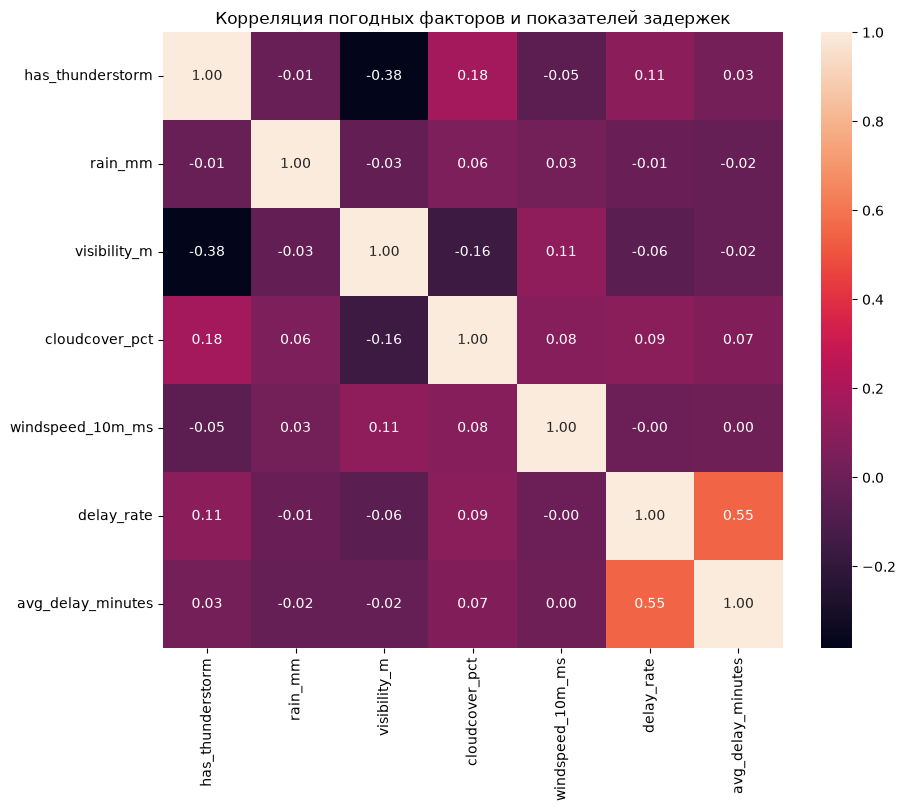

In [25]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Корреляция погодных факторов и показателей задержек')
plt.show()

## Вывод

Все коэффициенты находятся значительно ниже порога 0.2, который обычно рассматривается как начало слабой связи. Это означает, что на уровне агрегированной витрины выраженной линейной зависимости между отдельными погодными параметрами и долей задержанных рейсов обнаружить не удалось.

In [26]:
weather_df[['wind_category', 'delay_rate']].head()

,wind_category,delay_rate
0,light,1.0
1,light,1.0
2,calm,1.0
3,calm,1.0
4,calm,1.0


<Figure size 1000x600 with 0 Axes>

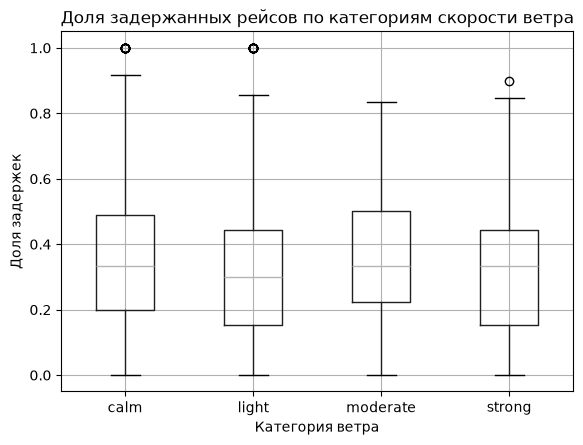

In [27]:
plt.figure(figsize=(10, 6))

weather_df.boxplot(
    column='delay_rate',
    by='wind_category'
)

plt.title('Доля задержанных рейсов по категориям скорости ветра')
plt.suptitle('')
plt.xlabel('Категория ветра')
plt.ylabel('Доля задержек')

plt.show()

In [30]:
weather_df['precipitation_category'].value_counts()

precipitation_category
none        1323
light        313
moderate      12
Name: count, dtype: int64

<Figure size 1000x600 with 0 Axes>

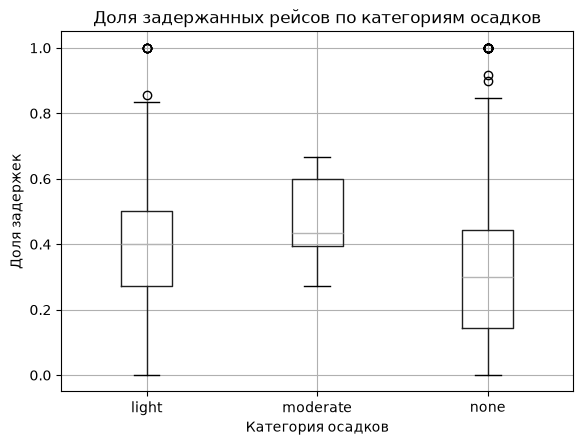

In [35]:
plt.figure(figsize=(10, 6))

weather_df.boxplot(
    column='delay_rate',
    by='precipitation_category'
)

plt.title('Доля задержанных рейсов по категориям осадков')
plt.suptitle('')
plt.xlabel('Категория осадков')
plt.ylabel('Доля задержек')

plt.show()

## Анализ влияния облачности

In [36]:
weather_df['cloudcover_category'].value_counts()

cloudcover_category
overcast         738
partly_cloudy    434
mostly_clear     230
mostly_cloudy    192
clear             54
Name: count, dtype: int64

<Figure size 1000x600 with 0 Axes>

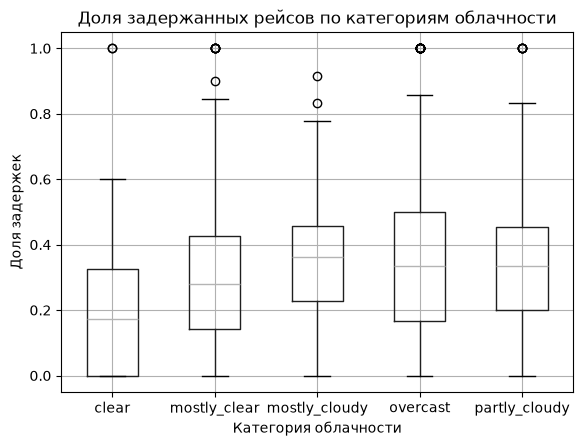

In [38]:
plt.figure(figsize=(10, 6))

weather_df.boxplot(
    column='delay_rate',
    by='cloudcover_category'
)

plt.title('Доля задержанных рейсов по категориям облачности')
plt.suptitle('')
plt.xlabel('Категория облачности')
plt.ylabel('Доля задержек')

plt.show()

In [39]:
weather_df['has_thunderstorm'].value_counts()

has_thunderstorm
False    1566
True       82
Name: count, dtype: int64

<Figure size 800x600 with 0 Axes>

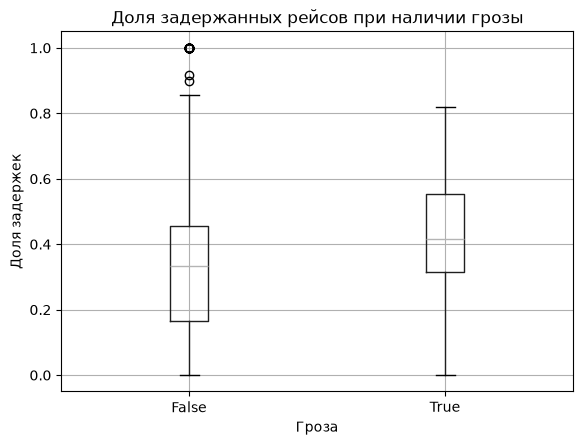

In [40]:
plt.figure(figsize=(8, 6))

weather_df.boxplot(
    column='delay_rate',
    by='has_thunderstorm'
)

plt.title('Доля задержанных рейсов при наличии грозы')
plt.suptitle('')
plt.xlabel('Гроза')
plt.ylabel('Доля задержек')

plt.show()

# Методы математической статистики

## Нулевая гипотеза: Наличие грозы не влияет на величину задержки рейса
## Альтернативная гипотеза: Наличие грозы влияет на величину задержки рейса

In [44]:
query = """
select

    f.flight_key,

    case
        when f.flight_direction = 'departure'
            then f.departure_delay_minutes
        when f.flight_direction = 'arrival'
            then f.arrival_delay_minutes
    end as delay_minutes,

    w.has_thunderstorm,
    w.is_strong_wind,
    w.is_low_visibility,
    w.is_heavy_precipitation,

    w.wind_category,
    w.visibility_category,
    w.precipitation_category

from analytics_core.fact_flights f

join analytics_core.fact_weather w

    on (
        case
            when f.flight_direction = 'departure'
                then f.scheduled_departure_utc

            when f.flight_direction = 'arrival'
                then f.scheduled_arrival_utc
            end
        )

        between
            w.weather_time_utc - interval '30 minutes'
        and
            w.weather_time_utc + interval '30 minutes'
"""

In [45]:
flight_weather_df = pd.read_sql(query, engine)

flight_weather_df.head()

,flight_key,delay_minutes,has_thunderstorm,is_strong_wind,is_low_visibility,is_heavy_precipitation,wind_category,visibility_category,precipitation_category
0,84e9bfa1c07c2788d127ac6a4ea0f632,0.0,False,False,False,False,calm,excellent,light
1,84e9bfa1c07c2788d127ac6a4ea0f632,0.0,False,False,False,False,calm,excellent,light
2,076e56bd877bf02f3dcde385dcb76016,-4.0,False,False,False,False,calm,excellent,light
3,076e56bd877bf02f3dcde385dcb76016,-4.0,False,False,False,False,calm,excellent,light
4,8816c007dca2263c702b3e13d5b6b700,0.0,False,True,False,False,strong,excellent,none


# Влияние Грозы

In [47]:
thunderstorm_group = flight_weather_df.loc[
    (flight_weather_df['has_thunderstorm'] == True)
    &
    (flight_weather_df['delay_minutes'] > 0),
    'delay_minutes'
    ]
normal_group = flight_weather_df.loc[
    (flight_weather_df['has_thunderstorm'] == False)
    &
    (flight_weather_df['delay_minutes'] > 0),
    'delay_minutes'
    ]

In [48]:
print(len(thunderstorm_group))
print(len(normal_group))

635
8930


In [49]:
print(thunderstorm_group.mean())
print(normal_group.mean())

33.91811023622047
34.04535274356103


In [50]:
print(thunderstorm_group.median())
print(normal_group.median())

22.0
19.0


In [51]:
thunderstorm_group.describe()

count    635.000000
mean      33.918110
std       42.652616
min        1.000000
25%       11.000000
50%       22.000000
75%       42.000000
max      489.000000
Name: delay_minutes, dtype: float64

In [52]:
normal_group.describe()

count    8930.000000
mean       34.045353
std        57.897694
min         1.000000
25%         8.000000
50%        19.000000
75%        38.000000
max       903.000000
Name: delay_minutes, dtype: float64

## Выбор метода
В данной выборке мы не можем использовать t-кретерий Стьюдента, тк он требует нормально распеределения. Мы же имеем дело с ассимитричным распеределением, поэтому будем использовать кретерий Манна-Уитни, тк он относится к непараметрическим статистическим тестам и не требует нормальности распределения

In [53]:
from scipy.stats import mannwhitneyu

In [54]:
statistic, p_value = mannwhitneyu(
    thunderstorm_group,
    normal_group,
    alternative='two-sided'
)
print(f'p-value: {p_value}, {statistic}')

p-value: 0.0005370269426913533, 3067954.5


## Вывод

Полученное значение p-value значительно меньше общепринятого уровня значимости 0.05 (p=0.000078). Это означает, что вероятность случайного возникновения наблюдаемых различий чрезвычайно мала. Следовательно, нулевая гипотеза отвергается. Полученный результат свидетельствует о наличии статистически значимых различий между задержками рейсов в периоды грозовой активности и в периоды отсутствия грозы.

# Z статистика

In [55]:
n1 = len(thunderstorm_group)
n2 = len(normal_group)

print(n1)
print(n2)

635
8930


In [56]:
import numpy as np

In [58]:
z = (
    statistic - (n1 * n2 / 2)
) / np.sqrt(
n1 * n2 * (n1 + n2 + 1) / 12
)
print(z)

3.4607558727418346


In [59]:
r = abs(z) / np.sqrt(n1 + n2)
print(r)

0.03538575590449162


Полученное значение существенно ниже порога малого эффекта. Это означает, что влияние грозовых условий на продолжительность задержек присутствует, однако его практическая выраженность невелика.

# Влияние сильного ветра

In [60]:
strong_wind_group = flight_weather_df.loc[
    (flight_weather_df['is_strong_wind'] == True)
    &
    (flight_weather_df['delay_minutes'] > 0),
    'delay_minutes'
]

normal_wind_group = flight_weather_df.loc[
    (flight_weather_df['is_strong_wind'] == False)
    &
    (flight_weather_df['delay_minutes'] > 0),
    'delay_minutes'
]

In [61]:
print(len(strong_wind_group))
print(len(normal_wind_group))

948
8617


In [62]:
statistic, p_value = mannwhitneyu(
    strong_wind_group,
    normal_wind_group,
    alternative='two-sided'
)

print(statistic)
print(p_value)

3958216.5
0.11763964314244071


In [63]:
n1 = len(strong_wind_group)
n2 = len(normal_wind_group)

z = (
    statistic - (n1 * n2 / 2)
) / np.sqrt(
    n1 * n2 * (n1 + n2 + 1) / 12
)

r = abs(z) / np.sqrt(n1 + n2)

print(r)

0.01599568630912313


Полученное значение существенно выше порога малого эффекта. Это означает, что влияние грозовых условий на продолжительность задержек отсутствует

# Интенсивные осадки

In [64]:
flight_weather_df['precipitation_category'].value_counts()

precipitation_category
none        12418
light        3271
moderate      145
Name: count, dtype: int64

In [65]:
precipitation_group = flight_weather_df.loc[
    (flight_weather_df['precipitation_category'] != 'none')
    &
    (flight_weather_df['delay_minutes'] > 0),
    'delay_minutes'
]

normal_precipitation_group = flight_weather_df.loc[
    (flight_weather_df['precipitation_category'] == 'none')
    &
    (flight_weather_df['delay_minutes'] > 0),
    'delay_minutes'
]

In [66]:
print(len(precipitation_group))
print(len(normal_precipitation_group))

2250
7315


In [67]:
print(precipitation_group.mean())
print(normal_precipitation_group.mean())

35.035555555555554
33.72973342447027


In [68]:
precipitation_group.describe()

count    2250.000000
mean       35.035556
std        53.166865
min         1.000000
25%        10.000000
50%        21.000000
75%        41.000000
max       903.000000
Name: delay_minutes, dtype: float64

In [69]:
normal_precipitation_group.describe()

count    7315.000000
mean       33.729733
std        58.141481
min         1.000000
25%         8.000000
50%        18.000000
75%        37.000000
max       850.000000
Name: delay_minutes, dtype: float64

In [70]:
statistic, p_value = mannwhitneyu(
    precipitation_group,
    normal_precipitation_group,
    alternative='two-sided'
)

print(statistic)
print(p_value)

8906541.5
3.3543709645288325e-09


In [71]:
n1 = len(precipitation_group)
n2 = len(normal_precipitation_group)
z = (
    statistic - (n1 * n2 / 2)
) / np.sqrt(
    n1 * n2 * (n1 + n2 + 1) / 12
)

r = abs(z) / np.sqrt(n1 + n2)

print(r)

0.06044772887873184


разница статистически высоко значима. Вероятность получить такой результат случайно практически низкая. Осадки действительно влияют на задержки.

Однако размер эффекта очень мал: r = 0.060. Это означает, что хотя различие статистически значимо, сила связи между осадками и задержкой рейсов крайне слабая

# Построение Логистической регресии

In [72]:
query = """
with flights as (
    select
        flight_key,
        case
            when flight_direction = 'departure'
                then scheduled_departure_utc
            when flight_direction = 'arrival'
                then scheduled_arrival_utc
        end as operation_ts,
        case
            when flight_direction = 'departure'
                then departure_delay_minutes
            when flight_direction = 'arrival'
                then arrival_delay_minutes
        end as delay_minutes
    from analytics_core.fact_flights
    where
        (
            flight_direction = 'departure'
            and airport_departure_iata = 'HKT'
        )
        or
        (
            flight_direction = 'arrival'
            and airport_arrival_iata = 'HKT'
        )
),

weather as (
    select
        weather_time_utc,
        temperature_2m_c,
        relative_humidity_2m_pct,
        precipitation_mm,
        visibility_m,
        cloudcover_pct,
        windspeed_10m_ms,
        has_thunderstorm
    from analytics_core.fact_weather
    where airport_iata = 'HKT'
)

select
    f.flight_key,
    f.operation_ts,
    w.weather_time_utc,
    f.delay_minutes,
    w.temperature_2m_c,
    w.relative_humidity_2m_pct,
    w.precipitation_mm,
    w.visibility_m,
    w.cloudcover_pct,
    w.windspeed_10m_ms,
    w.has_thunderstorm
from flights f

left join weather w
    on f.operation_ts between
        w.weather_time_utc - interval '30 minutes'
    and
        w.weather_time_utc + interval '30 minutes'
where f.delay_minutes is not null
"""

In [73]:
regression_df = pd.read_sql(
    query,
    engine
)

In [74]:
regression_df.shape

(15838, 11)

In [75]:
regression_df['flight_key'].nunique()

14562

In [76]:
(
    regression_df
    .groupby('flight_key')
    .size()
    .value_counts()
    .sort_index()
)

1    13286
2     1276
Name: count, dtype: int64

Некоторые рейсы встречаются дважды, для нашего анализа это критично. Поэтому оставим одно наблюдение для каждого рейса

In [78]:
regression_df['time_diff'] = (
    regression_df['operation_ts']
    -
    regression_df['weather_time_utc']
).abs()

In [79]:
regression_df = (
    regression_df
    .sort_values('time_diff')
    .drop_duplicates(
        subset='flight_key',
        keep='first'
    )
)

In [81]:
regression_df.shape

regression_df['flight_key'].nunique()

(14562, 12)

In [82]:
regression_df.isna().sum()

flight_key                  0
operation_ts                0
weather_time_utc            4
delay_minutes               0
temperature_2m_c            4
relative_humidity_2m_pct    4
precipitation_mm            4
visibility_m                4
cloudcover_pct              4
windspeed_10m_ms            4
has_thunderstorm            4
time_diff                   4
dtype: int64

In [83]:
regression_df = regression_df.dropna()

In [84]:
regression_df['delay_flag'] = (
    regression_df['delay_minutes'] > 10
).astype(int)

В результате было установлено, что около 64% наблюдений относятся к рейсам без существенной задержки, а около 36% наблюдений — к рейсам с задержкой более 10 минут. Подобное распределение считается достаточно сбалансированным для построения модели логистической регрессии. Оба класса представлены большим количеством наблюдений, поэтому модель сможет корректно обучаться без применения дополнительных методов балансировки данных.

In [85]:
regression_df['delay_flag'].value_counts()

delay_flag
0    8458
1    6100
Name: count, dtype: int64

In [86]:
features = [
    'temperature_2m_c',
    'relative_humidity_2m_pct',
    'precipitation_mm',
    'visibility_m',
    'cloudcover_pct',
    'windspeed_10m_ms',
    'has_thunderstorm'
]

X = regression_df[features]
y = regression_df['delay_flag']

Погодные показатели измеряются в разных единицах и имеют разные диапазоны значений — температура в градусах, видимость в метрах, осадки миллиметрах. Без предварительной обработки модель будет воспринимать признаки с большими числовыми значениями как более значимые. Для решения этой проблемы применяется стандартизация — она приводит все признаки к единому масштабу со средним 0 и стандартным отклонением 1 (X = regression_df[features] и y = regression_df['delay_flag']).

In [87]:
X.head()

,temperature_2m_c,relative_humidity_2m_pct,precipitation_mm,visibility_m,cloudcover_pct,windspeed_10m_ms,has_thunderstorm
8874,28.4,69.0,0.0,24140.0,34.0,14.3,False
12227,27.3,79.0,0.0,22680.0,80.0,5.8,False
12226,27.3,82.0,0.5,24140.0,98.0,9.2,False
12223,26.7,84.0,0.0,24140.0,100.0,12.7,False
12222,27.4,83.0,0.0,24140.0,100.0,2.9,False


In [88]:
X.isna().sum()

temperature_2m_c            0
relative_humidity_2m_pct    0
precipitation_mm            0
visibility_m                0
cloudcover_pct              0
windspeed_10m_ms            0
has_thunderstorm            0
dtype: int64

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [91]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)

(11646, 7)
(2912, 7)
(11646,)
(2912,)


In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
model = LogisticRegression(
    max_iter=1000
)

In [94]:
model.fit(
    X_train_scaled,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [95]:
y_pred = model.predict(X_test_scaled)

In [96]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [97]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.571771978021978


In [98]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.58      0.94      0.72      1688
           1       0.43      0.06      0.11      1224

    accuracy                           0.57      2912
   macro avg       0.51      0.50      0.41      2912
weighted avg       0.52      0.57      0.46      2912



In [99]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[1589,   99],
       [1148,   76]])

Полученные результаты позволяют сделать важный вывод. Несмотря на наличие статистически значимых связей между отдельными погодными факторами и задержками рейсов, погодные параметры сами по себе объясняют лишь небольшую часть случаев возникновения задержек. На регулярность выполнения рейсов, вероятно, оказывают влияние и другие факторы, не представленные в исследуемом наборе данных. К ним могут относиться загруженность аэропорта, ограничения воздушного движения, особенности расписания авиакомпаний, технические причины и задержки, возникающие на предыдущих этапах выполнения рейса.

In [100]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

coef_df


,feature,coefficient
0,temperature_2m_c,0.142967
4,cloudcover_pct,0.109692
2,precipitation_mm,0.076281
6,has_thunderstorm,0.003850
1,relative_humidity_2m_pct,-0.021927
5,windspeed_10m_ms,-0.026888
3,visibility_m,-0.028863


# Анализ погоды на вылеты из аэропорта

In [101]:
query = """
with flights as (

    select
        flight_key,
        scheduled_departure_utc as operation_ts,
        departure_delay_minutes as delay_minutes

    from analytics_core.fact_flights

    where flight_direction = 'departure'
      and airport_departure_iata = 'HKT'
      and departure_delay_minutes is not null

),

weather as (

    select
        weather_time_utc,
        temperature_2m_c,
        relative_humidity_2m_pct,
        precipitation_mm,
        visibility_m,
        cloudcover_pct,
        windspeed_10m_ms,
        has_thunderstorm,
        wind_category,
        precipitation_category,
        visibility_category

    from analytics_core.fact_weather
    where airport_iata = 'HKT'

)

select
    f.flight_key,
    f.operation_ts,
    w.weather_time_utc,
    f.delay_minutes,
    w.temperature_2m_c,
    w.relative_humidity_2m_pct,
    w.precipitation_mm,
    w.visibility_m,
    w.cloudcover_pct,
    w.windspeed_10m_ms,
    w.has_thunderstorm,
    w.wind_category,
    w.precipitation_category,
    w.visibility_category

from flights f

left join weather w
    on f.operation_ts >= w.weather_time_utc - interval '30 minutes'
   and f.operation_ts <  w.weather_time_utc + interval '30 minutes'

where w.weather_time_utc is not null
"""

dep_df = pd.read_sql(query, engine)

In [102]:
dep_df['time_diff'] = (
    dep_df['operation_ts'] - dep_df['weather_time_utc']
).abs()

dep_df = (
    dep_df
    .sort_values('time_diff')
    .drop_duplicates(subset='flight_key', keep='first')
    .dropna()
)

In [103]:
dep_df['delay_flag'] = (dep_df['delay_minutes'] > 10).astype(int)

In [104]:
print(dep_df.shape)
print(dep_df['delay_minutes'].describe())
print(dep_df['delay_flag'].value_counts())

(7298, 16)
count    7298.000000
mean       19.978761
std        51.550380
min      -184.000000
25%        -1.000000
50%         7.000000
75%        25.000000
max       885.000000
Name: delay_minutes, dtype: float64
delay_flag
0    4120
1    3178
Name: count, dtype: int64


## Уберем яные аномалии

In [105]:
dep_df = dep_df[dep_df['delay_minutes'] >= -120]

print(dep_df.shape)
print(dep_df['delay_minutes'].describe())
print(dep_df['delay_flag'].value_counts())

(7296, 16)
count    7296.000000
mean       20.026590
std        51.474101
min       -90.000000
25%        -1.000000
50%         7.000000
75%        25.000000
max       885.000000
Name: delay_minutes, dtype: float64
delay_flag
0    4118
1    3178
Name: count, dtype: int64


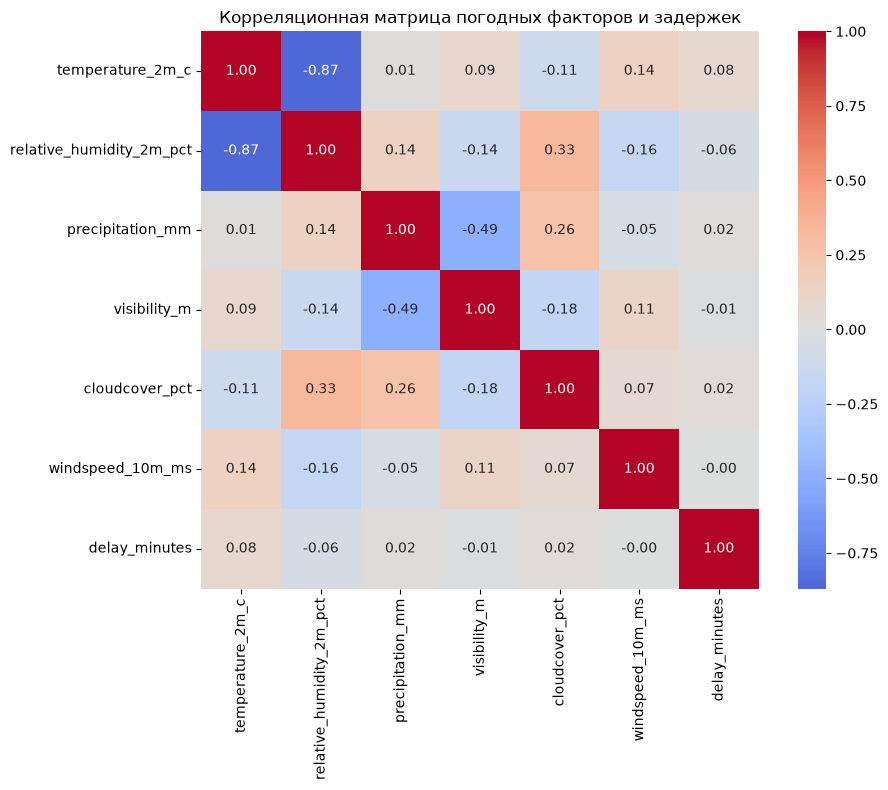

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

weather_features = [
    'temperature_2m_c',
    'relative_humidity_2m_pct',
    'precipitation_mm',
    'visibility_m',
    'cloudcover_pct',
    'windspeed_10m_ms',
    'delay_minutes'
]

corr_matrix = dep_df[weather_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Корреляционная матрица погодных факторов и задержек')
plt.tight_layout()
plt.show()

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

features = [
    'temperature_2m_c',
    'relative_humidity_2m_pct',
    'precipitation_mm',
    'visibility_m',
    'cloudcover_pct',
    'windspeed_10m_ms',
    'has_thunderstorm'
]

X = dep_df[features]
y = dep_df['delay_flag']

# Разделяем данные ДО стандартизации для предотвращения утечки данных
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print(coef_df)

              precision    recall  f1-score   support

           0       0.60      0.82      0.69       850
           1       0.48      0.23      0.31       610

    accuracy                           0.57      1460
   macro avg       0.54      0.53      0.50      1460
weighted avg       0.55      0.57      0.53      1460

[[700 150]
 [471 139]]
                    feature  coefficient
0          temperature_2m_c     0.125946
4            cloudcover_pct     0.114490
2          precipitation_mm     0.055910
5          windspeed_10m_ms     0.039036
6          has_thunderstorm     0.011879
3              visibility_m    -0.068938
1  relative_humidity_2m_pct    -0.111183


Анализ только вылетов из HKT дал более чистую картину, чем анализ всех операций, но принципиальный вывод не изменился. Ответ на вопрос «влияет ли погода на задержки вылетов из Пхукета»: влияет, но очень слабо. Задержки определяются преимущественно другими факторами — операционными, организационными, сетевыми — которые остались за пределами нашего набора данных.